Image A  shape=(448, 448)  min=0.0000  max=255.0000
Image B  shape=(448, 448)  min=0.0000  max=255.0000
Image B  noise pixels (>1000.0): 0  (0.00%)


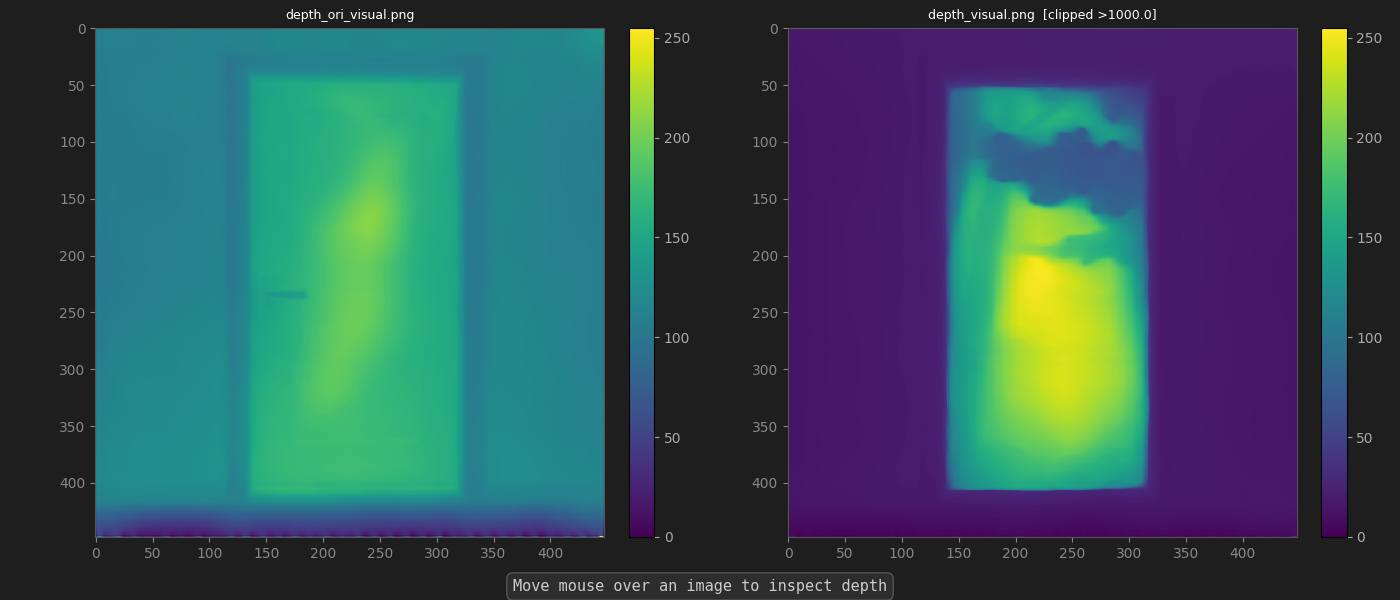

In [1]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ─────────────────────────────────────────────
# 配置：修改路径和阈值即可
# ─────────────────────────────────────────────
scene = 3
frame = 6
PATH_A = f'/home/discover/sam3d_gs/doors/20/depth_ori_visual.png'
PATH_B = f'/home/discover/sam3d_gs/doors/20/depth_visual.png'

CMAP    = 'viridis'   # 颜色映射，可改为 'jet' / 'plasma' / 'gray'
CLIP_B  = 1000.0      # Image B 超过此值的像素视为噪声，显示时遮蔽（hover 仍显示原始值）
# ─────────────────────────────────────────────


def load_depth(path: str) -> np.ndarray:
    """支持 .npz（含 'depth' key）/ .npy / .png / .jpg 等格式"""
    if path.endswith('.npz'):
        data = np.load(path)
        key = 'depth' if 'depth' in data else list(data.keys())[0]
        return data[key].astype(np.float32)
    elif path.endswith('.npy'):
        return np.load(path).astype(np.float32)
    else:
        img = Image.open(path)
        arr = np.array(img).astype(np.float32)
        if arr.ndim == 3:
            arr = arr[:, :, 0]
        return arr


depth_a = load_depth(PATH_A)
depth_b = load_depth(PATH_B)

# 用于显示的版本：噪声位置替换为 NaN（不影响 colormap 范围，且渲染为透明）
depth_b_display = depth_b.copy()
noise_mask = depth_b_display > CLIP_B
depth_b_display[noise_mask] = np.nan

noise_count = int(noise_mask.sum())
print(f'Image A  shape={depth_a.shape}  min={depth_a.min():.4f}  max={depth_a.max():.4f}')
print(f'Image B  shape={depth_b.shape}  min={depth_b.min():.4f}  max={depth_b.max():.4f}')
print(f'Image B  noise pixels (>{CLIP_B}): {noise_count}  ({100*noise_count/depth_b.size:.2f}%)')

# ── 绘图 ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.patch.set_facecolor('#1e1e1e')

display_data = [depth_a, depth_b_display]
raw_data     = [depth_a, depth_b]        # hover 读取原始值
titles       = [PATH_A.split('/')[-1], PATH_B.split('/')[-1] + f'  [clipped >{CLIP_B}]']

cmap_obj = plt.get_cmap(CMAP).copy()
cmap_obj.set_bad(color='#3a3a3a')        # NaN 显示为深灰色

ims = [
    axes[0].imshow(display_data[0], cmap=cmap_obj, interpolation='nearest'),
    axes[1].imshow(display_data[1], cmap=cmap_obj, interpolation='nearest'),
]

for ax, title, im in zip(axes, titles, ims):
    ax.set_title(title, color='white', fontsize=9, pad=6)
    ax.tick_params(colors='#888')
    for spine in ax.spines.values():
        spine.set_edgecolor('#555')
    ax.set_facecolor('#1e1e1e')
    cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.ax.yaxis.set_tick_params(color='#aaa')
    plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaa')

# ── 状态栏 ────────────────────────────────────
status = fig.text(
    0.5, 0.01,
    'Move mouse over an image to inspect depth',
    ha='center', va='bottom',
    color='#cccccc', fontsize=11,
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#2d2d2d', edgecolor='#555'),
)

cursors = [
    ax.plot([], [], '+', color='red', markersize=14, markeredgewidth=1.5)[0]
    for ax in axes
]

def on_move(event):
    for idx, ax in enumerate(axes):
        if event.inaxes is not ax:
            continue
        x, y = event.xdata, event.ydata
        if x is None or y is None:
            continue
        xi, yi = int(round(x)), int(round(y))
        d = raw_data[idx]
        H, W = d.shape
        if not (0 <= xi < W and 0 <= yi < H):
            continue

        val = d[yi, xi]
        label = 'A' if idx == 0 else 'B'
        noise_tag = '  [NOISE]' if (idx == 1 and val > CLIP_B) else ''
        status.set_text(
            f'Image {label}  |  pixel ({xi:4d}, {yi:4d})  |  depth = {val:.4f}{noise_tag}'
        )

        cursors[idx].set_data([xi], [yi])
        for i, c in enumerate(cursors):
            if i != idx:
                c.set_data([], [])

        fig.canvas.draw_idle()
        break

fig.canvas.mpl_connect('motion_notify_event', on_move)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()

In [ ]:
%matplotlib widget
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ─────────────────────────────────────────────
# 配置：修改路径和阈值即可
# ─────────────────────────────────────────────
scene = 3
frame = 6
PATH = f'/home/yuchi/Desktop/output_data_tmp_cam0_depth_only/{scene:05d}/images0/depth/images0_{frame}_raw.npz'
# PATH = f'/media/yuchi/WM/bridge_dataset/bridge_with_depth/datacol2_folding_table/{scene:05d}/depth_images0/im_{frame}.png'

CMAP    = 'viridis'   # 颜色映射，可改为 'jet' / 'plasma' / 'gray'
CLIP    = 1000.0      # 超过此值的像素视为噪声，显示时遮蔽（hover 仍显示原始值）
# ─────────────────────────────────────────────


def load_depth(path: str) -> np.ndarray:
    """支持 .npz（含 'depth' key）/ .npy / .png / .jpg 等格式"""
    if path.endswith('.npz'):
        data = np.load(path)
        key = 'depth' if 'depth' in data else list(data.keys())[0]
        return data[key].astype(np.float32)
    elif path.endswith('.npy'):
        return np.load(path).astype(np.float32)
    else:
        img = Image.open(path)
        arr = np.array(img).astype(np.float32)
        if arr.ndim == 3:
            arr = arr[:, :, 0]
        return arr


depth = load_depth(PATH)

# 用于显示的版本：噪声位置替换为 NaN
depth_display = depth.copy()
noise_mask = depth_display > CLIP
depth_display[noise_mask] = np.nan

noise_count = int(noise_mask.sum())
print(f'Depth  shape={depth.shape}  min={depth.min():.4f}  max={depth.max():.4f}')
print(f'Noise pixels (>{CLIP}): {noise_count}  ({100*noise_count/depth.size:.2f}%)')

# ── 绘图 ──────────────────────────────────────
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
fig.patch.set_facecolor('#1e1e1e')
ax.set_facecolor('#1e1e1e')

cmap_obj = plt.get_cmap(CMAP).copy()
cmap_obj.set_bad(color='#3a3a3a')  # NaN 显示为深灰色

im = ax.imshow(depth_display, cmap=cmap_obj, interpolation='nearest')

ax.set_title(PATH.split('/')[-1] + f'  [clipped >{CLIP}]', color='white', fontsize=9, pad=6)
ax.tick_params(colors='#888')
for spine in ax.spines.values():
    spine.set_edgecolor('#555')

cb = fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
cb.ax.yaxis.set_tick_params(color='#aaa')
plt.setp(cb.ax.yaxis.get_ticklabels(), color='#aaa')

# ── 状态栏 ────────────────────────────────────
status = fig.text(
    0.5, 0.01,
    'Move mouse over image to inspect depth',
    ha='center', va='bottom',
    color='#cccccc', fontsize=11,
    fontfamily='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='#2d2d2d', edgecolor='#555'),
)

cursor = ax.plot([], [], '+', color='red', markersize=14, markeredgewidth=1.5)[0]

def on_move(event):
    if event.inaxes is not ax:
        return
    x, y = event.xdata, event.ydata
    if x is None or y is None:
        return
    xi, yi = int(round(x)), int(round(y))
    H, W = depth.shape
    if not (0 <= xi < W and 0 <= yi < H):
        return

    val = depth[yi, xi]
    noise_tag = '  [NOISE]' if val > CLIP else ''
    status.set_text(
        f'pixel ({xi:4d}, {yi:4d})  |  depth = {val:.4f}{noise_tag}'
    )

    cursor.set_data([xi], [yi])
    fig.canvas.draw_idle()

fig.canvas.mpl_connect('motion_notify_event', on_move)
plt.tight_layout(rect=[0, 0.05, 1, 1])
plt.show()